<a href="https://colab.research.google.com/github/ItzNotCheetah/XGB-Cascade-Classifier/blob/main/cifar10_xgb_cascade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cost-Sensitive Real-Time Cascading Router Engine
This notebook implements a dynamic IDK ("I Don't Know") cascade scheduling framework using real PyTorch feature extractions on the CIFAR-10 dataset combined with an asymmetric XGBoost meta-classifier.

In [1]:
# Cell 1: Environment Installation
!pip install xgboost scikit-learn pandas numpy torch torchvision

In [2]:
# Cell 2: Dependencies and Device Setup
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import numpy as np
import pandas as pd
import xgboost as xgb
import time
from sklearn.model_selection import train_test_split

# Force GPU acceleration if available on Colab
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using execution device: {device}")

Using execution device: cpu


In [3]:
# Cell 3: Loading CIFAR-10 Native Pre-trained Networks
print("Loading CIFAR-10 native pretrained networks from torch.hub...")

# Model A: Front-End Lightweight Model (ResNet-20)
model_a = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet20", pretrained=True).to(device)
model_a.eval()

# Model B: Intermediate Model (ResNet-32)
model_b = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet32", pretrained=True).to(device)
model_b.eval()

# Model C: Heavy Expert Fallback Model (ResNet-56)
model_c = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet56", pretrained=True).to(device)
model_c.eval()

# Configure data transformation using native CIFAR-10 normalization metrics (32x32 resolution)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
])

# Download the validation split
val_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
torch.manual_seed(42)
indices = torch.randperm(len(val_dataset))[:2000] # 2000 sample evaluation subset
val_subset = torch.utils.data.Subset(val_dataset, indices)
val_loader = torch.utils.data.DataLoader(val_subset, batch_size=32, shuffle=False)

print("Models and datasets loaded successfully.")

Loading CIFAR-10 native pretrained networks from torch.hub...
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/resnet/cifar10_resnet20-4118986f.pt" to /root/.cache/torch/hub/checkpoints/cifar10_resnet20-4118986f.pt


100%|██████████| 1.09M/1.09M [00:00<00:00, 33.0MB/s]
Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/resnet/cifar10_resnet32-ef93fc4d.pt" to /root/.cache/torch/hub/checkpoints/cifar10_resnet32-ef93fc4d.pt


100%|██████████| 1.85M/1.85M [00:00<00:00, 42.8MB/s]
Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/resnet/cifar10_resnet56-187c023a.pt" to /root/.cache/torch/hub/checkpoints/cifar10_resnet56-187c023a.pt


100%|██████████| 3.39M/3.39M [00:00<00:00, 65.5MB/s]
100%|██████████| 170M/170M [35:44<00:00, 79.5kB/s]


Models and datasets loaded successfully.


In [4]:
# Cell 4: Empirically Measuring Live Latencies
def measure_latency(model, sample_batch, n_reps=50, device=device):
    model.eval()
    with torch.no_grad():
        # Hardware Warmup passes
        for _ in range(10):
            _ = model(sample_batch)

        if device.type == "cuda":
            torch.cuda.synchronize()

        start = time.perf_counter()
        for _ in range(n_reps):
            _ = model(sample_batch)

        if device.type == "cuda":
            torch.cuda.synchronize()
        end = time.perf_counter()

    # Calculate millisecond latency cost scaled per single image
    return (end - start) / n_reps * 1000 / sample_batch.size(0)

# Extract a live batch to run physical performance analysis
sample_batch = next(iter(val_loader))[0].to(device)

print("Profiling physical execution footprints on current hardware...")
LATENCY_A = measure_latency(model_a, sample_batch)
LATENCY_B = measure_latency(model_b, sample_batch)
LATENCY_C = measure_latency(model_c, sample_batch)

print(f"\n[METRIC] Measured Latencies — Model A: {LATENCY_A:.3f} ms, Model B: {LATENCY_B:.3f} ms, Model C: {LATENCY_C:.3f} ms")

Profiling physical execution footprints on current hardware...

[METRIC] Measured Latencies — Model A: 1.279 ms, Model B: 2.111 ms, Model C: 3.853 ms


In [ ]:
# Cell 5: Live Feature Extraction & Real Evaluation
print("Extracting multi-parameter uncertainty vectors from live network outputs...")

features_list = []
targets_list = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        # 1. Evaluate Model A outputs
        outputs_a = model_a(images)
        probs_a = torch.softmax(outputs_a, dim=1)

        conf_A, preds_a = torch.max(probs_a, dim=1)
        entropy_A = -torch.sum(probs_a * torch.log(probs_a + 1e-6), dim=1)
        top_2_vals, _ = torch.topk(probs_a, k=2, dim=1)
        margin_A = top_2_vals[:, 0] - top_2_vals[:, 1]

        # 2. Evaluate Model B outputs
        outputs_b = model_b(images)
        _, preds_b = torch.max(outputs_b, dim=1)

        # Ground Truth: 1 if Model B succeeds, 0 if it fails (requiring a skip to C)
        actual_b_status = (preds_b == labels).long()

        # 3. Evaluate Model C outputs for ground-truth tracking
        outputs_c = model_c(images)
        _, preds_c = torch.max(outputs_c, dim=1)

        for i in range(images.size(0)):
            features_list.append({
                'confidence': conf_A[i].item(),
                'entropy': entropy_A[i].item(),
                'margin': margin_A[i].item(),
                'correct_a': (preds_a[i] == labels[i]).item(),
                'correct_b': (preds_b[i] == labels[i]).item(),
                'correct_c': (preds_c[i] == labels[i]).item()
            })
            targets_list.append(actual_b_status[i].item())

telemetry_df = pd.DataFrame(features_list)
telemetry_df['target_skip'] = targets_list

print(f"\nTelemetry complete. Shape: {telemetry_df.shape}")
print(f"Class Distribution -> Model B Success (1): {np.sum(telemetry_df['target_skip'] == 1)} | Model B Failure (0): {np.sum(telemetry_df['target_skip'] == 0)}")

In [6]:
# Cell 6: Dynamic Asymmetric Cost Parameter Tuning
X = telemetry_df[['confidence', 'entropy', 'margin']]
y = telemetry_df['target_skip']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
indices_test = X_test.index

# Define empirical cost-penalty formulations
cost_of_missed_skip = LATENCY_B + LATENCY_C
cost_of_unnecessary_skip = LATENCY_C - LATENCY_B
asymmetric_cost_multiplier = cost_of_missed_skip / max(cost_of_unnecessary_skip, 1e-6)

num_pos = np.sum(y_train == 1)
num_neg = np.sum(y_train == 0)
base_scale_pos_weight = num_neg / max(num_pos, 1)

# Dynamically apply empirical cost weight balancing
tuned_scale_weight = base_scale_pos_weight * asymmetric_cost_multiplier

print(f"Calculated Asymmetric Scale Weight: {tuned_scale_weight:.4f}")

xgb_router = xgb.XGBClassifier(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.1,
    scale_pos_weight=tuned_scale_weight,
    eval_metric='logloss',
    random_state=42
)
xgb_router.fit(X_train, y_train)
print("XGBoost Meta-Router trained successfully.")

Calculated Asymmetric Scale Weight: 0.2210
XGBoost Meta-Router trained successfully.


In [19]:
def evaluate_cascades(features, test_indices, true_labels):
    eval_size = len(features)
    raw_df = telemetry_df.loc[test_indices].reset_index(drop=True)

    # 1. EXTRACT RAW PROBABILITIES (Put this right before the sweeps)
    xgb_probabilities = xgb_router.predict_proba(features)[:, 1]

    threshold_sweep = [0.01, 0.05, 0.10, 0.20, 0.40, 0.60, 0.80, 0.95, 0.99]
    summary_rows = []

    # --- Strategy 1: Standard Linear Cascade Baseline ---
    time_linear = 0.0
    correct_linear = 0
    for idx in range(eval_size):
        time_linear += LATENCY_A + LATENCY_B
        if raw_df.loc[idx, 'correct_b']:
            correct_linear += 1
        else:
            time_linear += LATENCY_C
            if raw_df.loc[idx, 'correct_c']:
                correct_linear += 1

    avg_latency_linear = time_linear / eval_size
    summary_rows.append({
        'Strategy': 'Standard Linear Cascade',
        'Skip Recall': 'N/A',
        'Avg Latency (ms)': round(avg_latency_linear, 2),
        'End-to-End Accuracy': f"{(correct_linear / eval_size) * 100:.2f}%",
        'Delta vs Linear (%)': '0.00%',
        'Delta vs Threshold (%)': 'N/A'
    })

    # --- Strategy 2: Rigid Threshold Skipping Standard (<0.3) ---
    time_threshold = 0.0
    correct_threshold = 0
    total_needed_skips = np.sum(raw_df['correct_b'] == 0)
    successful_threshold_skips = 0

    for idx in range(eval_size):
        time_threshold += LATENCY_A
        if raw_df.loc[idx, 'confidence'] < 0.3:
            time_threshold += LATENCY_C
            if raw_df.loc[idx, 'correct_b'] == 0:
                successful_threshold_skips += 1
            if raw_df.loc[idx, 'correct_c']:
                correct_threshold += 1
        else:
            time_threshold += LATENCY_B
            if raw_df.loc[idx, 'correct_b']:
                correct_threshold += 1
            else:
                time_threshold += LATENCY_C
                if raw_df.loc[idx, 'correct_c']:
                    correct_threshold += 1

    avg_latency_thresh = time_threshold / eval_size
    thresh_recall = (successful_threshold_skips / total_needed_skips) * 100 if total_needed_skips > 0 else 0
    delta_thresh_vs_linear = ((avg_latency_linear - avg_latency_thresh) / avg_latency_linear) * 100

    summary_rows.append({
        'Strategy': 'Static Threshold (<0.3)',
        'Skip Recall': f"{thresh_recall:.2f}%",
        'Avg Latency (ms)': round(avg_latency_thresh, 2),
        'End-to-End Accuracy': f"{(correct_threshold / eval_size) * 100:.2f}%",
        'Delta vs Linear (%)': f"{delta_thresh_vs_linear:+.2f}%",
        'Delta vs Threshold (%)': '0.00%'
    })

    # --- Strategy 3: Dynamic XGBoost Sweeps ---
    for current_threshold in threshold_sweep:
        # 2. FORCE EVALUATION AT THE CURRENT SWEEP THRESHOLD
        xgb_decisions = np.where(xgb_probabilities >= current_threshold, 1, 0)

        time_smart_xgb = 0.0
        correct_xgb = 0
        successful_xgb_skips = 0

        for idx in range(eval_size):
            time_smart_xgb += LATENCY_A

            if xgb_decisions[idx] == 0:  # Router flags skip
                time_smart_xgb += LATENCY_C
                if raw_df.loc[idx, 'correct_b'] == 0:
                    successful_xgb_skips += 1
                if raw_df.loc[idx, 'correct_c']:
                    correct_xgb += 1
            else:  # Router flags use B
                time_smart_xgb += LATENCY_B
                if raw_df.loc[idx, 'correct_b']:
                    correct_xgb += 1
                else:
                    time_smart_xgb += LATENCY_C
                    if raw_df.loc[idx, 'correct_c']:
                        correct_xgb += 1

        avg_latency_xgb = time_smart_xgb / eval_size
        xgb_recall = (successful_xgb_skips / total_needed_skips) * 100 if total_needed_skips > 0 else 0

        delta_vs_linear = ((avg_latency_linear - avg_latency_xgb) / avg_latency_linear) * 100
        delta_vs_thresh = ((avg_latency_thresh - avg_latency_xgb) / avg_latency_thresh) * 100

        summary_rows.append({
            'Strategy': f'XGBoost Cascade (θ={current_threshold:.2f})',
            'Skip Recall': f"{xgb_recall:.2f}%",
            'Avg Latency (ms)': round(avg_latency_xgb, 2),
            'End-to-End Accuracy': f"{(correct_xgb / eval_size) * 100:.2f}%",
            'Delta vs Linear (%)': f"{delta_vs_linear:+.2f}%",
            'Delta vs Threshold (%)': f"{delta_vs_thresh:+.2f}%"
        })

    result_grid = pd.DataFrame(summary_rows)
    return result_grid

In [25]:
# Force execution of your updated sweep logic on your current test split
research_grid = evaluate_cascades(X_test, indices_test, y_test)

# Force the notebook to display the entire pandas DataFrame
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print("--- Dynamic Cascade Sweep Results ---")
research_grid

--- Dynamic Cascade Sweep Results ---


,Strategy,Skip Recall,Avg Latency (ms),End-to-End Accuracy,Delta vs Linear (%),Delta vs Threshold (%)
0,Standard Linear Cascade,N/A,3.64,97.50%,0.00%,N/A
1,Static Threshold (<0.3),0.00%,3.64,97.50%,+0.00%,0.00%
2,XGBoost Cascade (θ=0.01),0.00%,3.64,97.50%,+0.00%,+0.00%
3,XGBoost Cascade (θ=0.05),0.00%,3.64,97.50%,+0.00%,+0.00%
4,XGBoost Cascade (θ=0.10),0.00%,3.64,97.50%,+0.00%,+0.00%
5,XGBoost Cascade (θ=0.20),0.00%,3.64,97.50%,+0.00%,+0.00%
6,XGBoost Cascade (θ=0.40),50.00%,3.73,95.25%,-2.54%,-2.54%
7,XGBoost Cascade (θ=0.60),61.54%,3.74,95.00%,-2.70%,-2.70%
8,XGBoost Cascade (θ=0.80),73.08%,3.95,94.25%,-8.61%,-8.61%
9,XGBoost Cascade (θ=0.95),84.62%,4.17,94.25%,-14.39%,-14.39%


In [22]:
# Cell 8: Router Micro-Overhead Benchmarking
# Answers: does the XGBoost prediction call itself eat the savings from skipping B?

n_overhead_reps = 100
router_times = []

for _ in range(n_overhead_reps):
    start_router = time.perf_counter()
    _ = xgb_router.predict_proba(X_test)
    end_router = time.perf_counter()
    router_times.append((end_router - start_router) / len(X_test) * 1000)  # ms per sample

router_overhead_per_sample = np.mean(router_times)
router_overhead_std = np.std(router_times)

print(f"[METRIC] Router Micro-Overhead: {router_overhead_per_sample:.4f} ± {router_overhead_std:.4f} ms/sample")
print(f"[METRIC] Overhead as % of Model A latency: {(router_overhead_per_sample / LATENCY_A) * 100:.2f}%")
print(f"[METRIC] Overhead as % of total linear cascade latency: "
      f"{(router_overhead_per_sample / (LATENCY_A + LATENCY_B)) * 100:.2f}%")

[METRIC] Router Micro-Overhead: 0.0020 ± 0.0007 ms/sample
[METRIC] Overhead as % of Model A latency: 0.16%
[METRIC] Overhead as % of total linear cascade latency: 0.06%


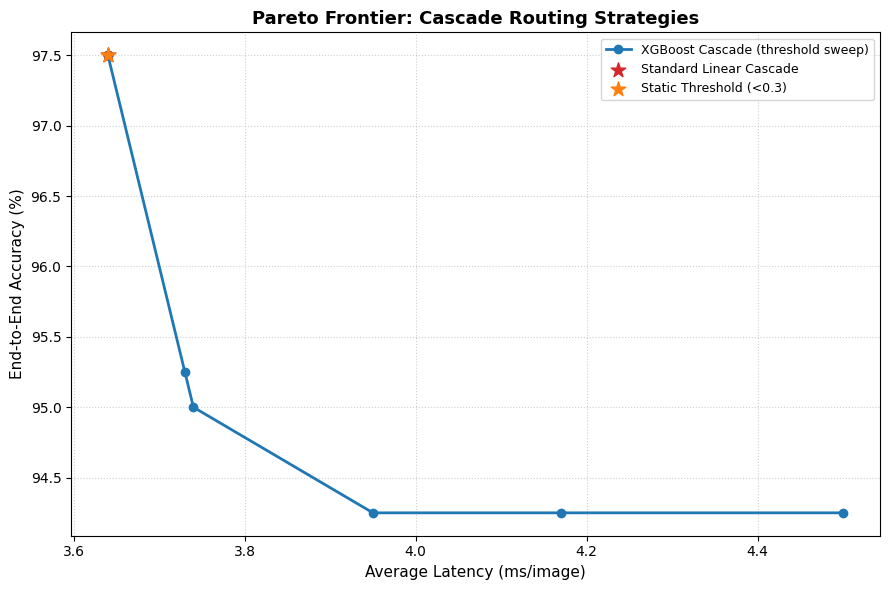

In [23]:
import matplotlib.pyplot as plt
import re

def parse_ms(s):
    # This function is no longer strictly necessary if 'Avg Latency (ms)' is already numeric,
    # but we'll keep it for clarity in case the data source changes or for other string parsing needs.
    # However, for the current data, the 'replace' part is causing the error if applied to a float.
    # Given the previous context, the column is already a float, so we simply return it as is if it's numeric.
    if isinstance(s, (int, float)):
        return float(s)
    return float(s.replace(' ms', ''))

def parse_pct(s):
    if s == 'N/A':
        return None
    return float(s.replace('%', ''))

plot_df = research_grid.copy()
# 'Avg Latency (ms)' is already a float, so direct assignment is appropriate.
plot_df['latency_val'] = plot_df['Avg Latency (ms)']
plot_df['accuracy_val'] = plot_df['End-to-End Accuracy'].apply(parse_pct)

fig, ax = plt.subplots(figsize=(9, 6))

xgb_rows = plot_df[plot_df['Strategy'].str.contains('XGBoost')]
baseline_rows = plot_df[~plot_df['Strategy'].str.contains('XGBoost')]

ax.plot(xgb_rows['latency_val'], xgb_rows['accuracy_val'],
        marker='o', color='tab:blue', linewidth=2, label='XGBoost Cascade (threshold sweep)')

for _, row in baseline_rows.iterrows():
    ax.scatter(row['latency_val'], row['accuracy_val'], s=120, marker='*',
               color='tab:red' if 'Linear' in row['Strategy'] else 'tab:orange',
               label=row['Strategy'], zorder=5)

ax.set_xlabel('Average Latency (ms/image)', fontsize=11)
ax.set_ylabel('End-to-End Accuracy (%)', fontsize=11)
ax.set_title('Pareto Frontier: Cascade Routing Strategies', fontsize=13, fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

In [26]:
# Cell 10: Multi-Seed Statistical Robustness Check
def run_single_trial(seed, n_samples=2000, threshold=0.10):
    torch.manual_seed(seed)
    trial_indices = torch.randperm(len(val_dataset))[:n_samples]
    trial_subset = torch.utils.data.Subset(val_dataset, trial_indices)
    trial_loader = torch.utils.data.DataLoader(trial_subset, batch_size=32, shuffle=False)

    feats, targs = [], []
    with torch.no_grad():
        for images, labels in trial_loader:
            images, labels = images.to(device), labels.to(device)
            outputs_a = model_a(images)
            probs_a = torch.softmax(outputs_a, dim=1)
            conf_A, preds_a = torch.max(probs_a, dim=1)
            entropy_A = -torch.sum(probs_a * torch.log(probs_a + 1e-6), dim=1)
            top_2_vals, _ = torch.topk(probs_a, k=2, dim=1)
            margin_A = top_2_vals[:, 0] - top_2_vals[:, 1]

            outputs_b = model_b(images)
            _, preds_b = torch.max(outputs_b, dim=1)
            actual_b_status = (preds_b == labels).long()

            outputs_c = model_c(images)
            _, preds_c = torch.max(outputs_c, dim=1)

            for i in range(images.size(0)):
                feats.append({
                    'confidence': conf_A[i].item(),
                    'entropy': entropy_A[i].item(),
                    'margin': margin_A[i].item(),
                    'correct_b': (preds_b[i] == labels[i]).item(),
                    'correct_c': (preds_c[i] == labels[i]).item()
                })
                targs.append(actual_b_status[i].item())

    df = pd.DataFrame(feats)
    df['target_skip'] = targs

    X_tr, X_te, y_tr, y_te = train_test_split(
        df[['confidence', 'entropy', 'margin']], df['target_skip'],
        test_size=0.2, random_state=seed
    )
    raw_te = df.loc[X_te.index].reset_index(drop=True)

    num_pos = np.sum(y_tr == 1)
    num_neg = np.sum(y_tr == 0)
    base_w = num_neg / max(num_pos, 1)
    tuned_w = base_w * asymmetric_cost_multiplier

    router = xgb.XGBClassifier(
        n_estimators=50, max_depth=3, learning_rate=0.1,
        scale_pos_weight=tuned_w, eval_metric='logloss', random_state=seed
    )
    router.fit(X_tr, y_tr)

    probs = router.predict_proba(X_te)[:, 1]
    decisions = np.where(probs >= threshold, 1, 0)

    total_latency, correct, needed_skips, hit_skips = 0.0, 0, 0, 0
    for idx in range(len(raw_te)):
        total_latency += LATENCY_A
        if raw_te.loc[idx, 'correct_b'] == 0:
            needed_skips += 1
        if decisions[idx] == 0:
            total_latency += LATENCY_C
            if raw_te.loc[idx, 'correct_b'] == 0:
                hit_skips += 1
            if raw_te.loc[idx, 'correct_c']:
                correct += 1
        else:
            total_latency += LATENCY_B
            if raw_te.loc[idx, 'correct_b']:
                correct += 1
            else:
                total_latency += LATENCY_C
                if raw_te.loc[idx, 'correct_c']:
                    correct += 1

    return {
        'seed': seed,
        'avg_latency': total_latency / len(raw_te),
        'accuracy': (correct / len(raw_te)) * 100,
        'skip_recall': (hit_skips / needed_skips) * 100 if needed_skips > 0 else 0
    }

print("Running multi-seed robustness check (this re-samples, retrains, and re-evaluates 5x)...")
trial_results = [run_single_trial(seed=s) for s in [1, 2, 3, 4, 5]]
trial_df = pd.DataFrame(trial_results)

print("\n--- Per-Seed Results ---")
print(trial_df)

print("\n--- Aggregate Statistics (mean ± std across 5 seeds) ---")
print(f"Avg Latency:  {trial_df['avg_latency'].mean():.2f} ± {trial_df['avg_latency'].std():.2f} ms")
print(f"Accuracy:     {trial_df['accuracy'].mean():.2f} ± {trial_df['accuracy'].std():.2f} %")
print(f"Skip Recall:  {trial_df['skip_recall'].mean():.2f} ± {trial_df['skip_recall'].std():.2f} %")

Running multi-seed robustness check (this re-samples, retrains, and re-evaluates 5x)...

--- Per-Seed Results ---
   seed  avg_latency  accuracy  skip_recall
0     1     3.544800     97.50          0.0
1     2     3.689297     95.75          0.0
2     3     3.612232     97.75          0.0
3     4     3.621865     97.00          0.0
4     5     3.641132     96.25          0.0

--- Aggregate Statistics (mean ± std across 5 seeds) ---
Avg Latency:  3.62 ± 0.05 ms
Accuracy:     96.85 ± 0.84 %
Skip Recall:  0.00 ± 0.00 %
